<a href="https://colab.research.google.com/github/nongolosh/TTX-disease-in-children-due-to-climate-change-/blob/main/Climate_Health_Risk_Kids_Under_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This code cell is primarily used for importing a comprehensive set of Python libraries essential for data analysis, machine learning model building, evaluation, and deep learning tasks. It prepares the environment by bringing in tools for numerical operations, data manipulation, visualization, various machine learning algorithms, handling imbalanced datasets, and constructing neural networks.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score,recall_score, classification_report, precision_recall_curve, f1_score, accuracy_score, roc_curve, roc_auc_score, auc
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.backend import dropout
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.metrics import Precision, Recall, AUC

In [ ]:
from sklearn.ensemble import RandomForestRegressor

Importing the dataset and provision of concise summary of its structure.

In [ ]:

df = pd.read_csv('CARES.csv')
df = df.dropna()
# Encoding categorical features
df['elevation_zone'] = df['elevation_zone'].replace({'lowland':0, 'foothill':1, 'highland':2})
df['highland'] = df['highland'].replace({'False':0, 'True':1})
df['risk_level'] = df['risk_level'].replace({'Low':0, 'Medium':1, 'High':2})


Exploratory Data Analysis AND Preprocessing







In [ ]:
df.head()


,year,month,district,community,record_type,elevation_zone,highland,u5_population,rainfall_mm,temperature_min_c,...,sam_rate_per1000,sam_cases_u5,safe_water_pct,improved_sanit_pct,stunting_pct_dhs,wasting_pct_dhs,mean_altitude_m,urban_pct,risk_score,risk_level
0,2022,1,Berea,Teyateyaneng,community,1,False,2226,94.1,15.3,...,16.3,40,87.1,65.2,16.9,0.7,1707,38.6,66.8,1
1,2022,1,Berea,Roma,community,1,False,2332,102.2,17.4,...,14.4,44,78.1,64.3,16.9,0.7,1707,38.6,69.2,1
2,2022,1,Berea,Mapoteng,community,1,False,2352,82.6,15.5,...,15.3,32,100.0,77.2,16.9,0.7,1707,38.6,60.0,1
3,2022,1,Berea,Kolonyama,community,1,False,2271,83.6,17.2,...,17.5,49,97.3,61.9,16.9,0.7,1707,38.6,67.1,1
4,2022,1,Berea,Ha Thetsane,community,1,False,2210,95.2,16.3,...,18.2,32,79.4,74.9,16.9,0.7,1707,38.6,62.1,1


In [ ]:
df = df.drop(columns=['district', 'community', 'record_type'], errors='ignore')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4068 entries, 0 to 4067
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    4068 non-null   int64  
 1   month                   4068 non-null   int64  
 2   elevation_zone          4068 non-null   int64  
 3   highland                4068 non-null   bool   
 4   u5_population           4068 non-null   int64  
 5   rainfall_mm             4068 non-null   float64
 6   temperature_min_c       4068 non-null   float64
 7   temperature_max_c       4068 non-null   float64
 8   temperature_mean_c      4068 non-null   float64
 9   frost_days              4068 non-null   int64  
 10  spi_drought_index       4068 non-null   float64
 11  snow_access_risk        4068 non-null   int64  
 12  diarrhoea_rate_per1000  4068 non-null   float64
 13  diarrhoea_cases_u5      4068 non-null   int64  
 14  ari_rate_per1000        4068 non-null   

In [ ]:
df.describe()

,year,month,elevation_zone,u5_population,rainfall_mm,temperature_min_c,temperature_max_c,temperature_mean_c,frost_days,spi_drought_index,...,sam_rate_per1000,sam_cases_u5,safe_water_pct,improved_sanit_pct,stunting_pct_dhs,wasting_pct_dhs,mean_altitude_m,urban_pct,risk_score,risk_level
count,4068.000000,4068.000000,4068.000000,4068.000000,4068.000000,4068.000000,4068.000000,4068.000000,4068.000000,4068.000000,...,4068.000000,4068.000000,4068.000000,4068.000000,4068.000000,4068.000000,4068.000000,4068.000000,4068.000000,4068.000000
mean,2023.000000,6.500000,0.920354,2519.167896,57.888717,7.814725,17.814725,12.814725,5.696411,0.344575,...,23.082793,56.177729,85.285398,62.040462,15.761062,0.844248,1836.796460,33.353097,55.757227,0.914700
std,0.816597,3.452477,0.873931,496.419754,40.557183,6.536600,6.536600,6.536600,7.823038,1.760282,...,12.681032,29.929162,9.608372,13.177991,3.815192,0.360461,232.334969,13.740614,10.781350,0.530227
min,2022.000000,1.000000,0.000000,1393.000000,3.700000,-8.800000,1.200000,-3.800000,0.000000,-2.470000,...,4.100000,8.000000,48.300000,26.300000,9.700000,0.000000,1641.000000,12.800000,28.700000,0.000000
25%,2022.000000,3.750000,0.000000,2164.000000,17.875000,2.200000,12.200000,7.200000,0.000000,-0.752500,...,14.100000,35.000000,79.075000,52.075000,11.500000,0.700000,1707.000000,28.700000,46.700000,1.000000
50%,2023.000000,6.500000,1.000000,2367.000000,55.300000,8.600000,18.600000,13.600000,2.000000,0.020000,...,20.300000,49.000000,85.900000,61.200000,16.900000,0.900000,1725.000000,30.200000,55.700000,1.000000
75%,2024.000000,9.250000,2.000000,2808.750000,87.100000,13.400000,23.400000,18.400000,9.000000,1.000000,...,28.800000,70.000000,92.500000,72.000000,20.100000,1.000000,1976.000000,38.000000,64.400000,1.000000
max,2024.000000,12.000000,2.000000,4017.000000,231.700000,20.600000,30.600000,25.600000,43.000000,29.370000,...,106.400000,255.000000,100.000000,100.000000,20.700000,1.600000,2348.000000,61.300000,83.600000,2.000000




This code is performing what's known as 'label encoding' on two categorical columns in your df DataFrame. It's converting textual categories into numerical representations, which is necessary for most machine learning algorithms.



This code is designed to help you understand the distribution of different 'risk_level' categories in your dataset

risk_level
1    2895
0     760
2     413
Name: count, dtype: int64


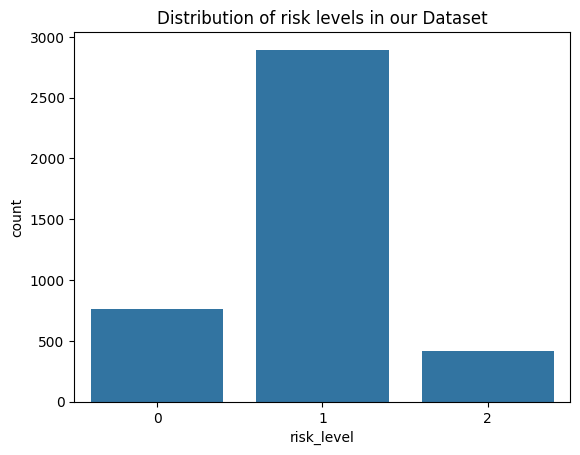

In [ ]:
sns.countplot(x='risk_level', data=df)

plt.title('Distribution of risk levels in our Dataset')
category_counts = df['risk_level'].value_counts()
print(category_counts)

In [ ]:
X = df.drop('risk_level', axis=1)
y = df['risk_level']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.80, random_state=42)


### Feature Importance for `risk_score` (Regression Task)

As `risk_score` is a continuous variable, we will now treat this as a regression problem. The steps are similar to the classification task but use a `RandomForestRegressor` instead of a `RandomForestClassifier` and omit SMOTE.

In [ ]:
# Redefine X and y for risk_score as the target
y_reg = df['risk_score']
X_reg = df.drop(columns=['risk_score', 'risk_level'], errors='ignore')

# Define columns to drop from the feature set for regression
# These include columns previously dropped and 'risk_level' which is now not the target
columns_to_drop_reg = [
    'year', 'month', 'elevation_zone', 'highland', 'u5_population',
    'temperature_min_c', 'temperature_max_c'
]

X_reg = X_reg.drop(columns=columns_to_drop_reg, errors='ignore')

# Split the data into training and testing sets for regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, train_size=0.80, random_state=42)

print(f"Shape of X_train_reg: {X_train_reg.shape}")
print(f"Shape of X_test_reg: {X_test_reg.shape}")

Shape of X_train_reg: (3254, 17)
Shape of X_test_reg: (814, 17)


In [ ]:
# Scale the data for regression
scaler_reg = StandardScaler()
X_train_scaled_reg = scaler_reg.fit_transform(X_train_reg)
X_test_scaled_reg = scaler_reg.transform(X_test_reg)

# Convert back to DataFrame for consistency
X_train_scaled_df_reg = pd.DataFrame(X_train_scaled_reg, columns=X_train_reg.columns, index=X_train_reg.index)
X_test_scaled_df_reg = pd.DataFrame(X_test_scaled_reg, columns=X_test_reg.columns, index=X_test_reg.index)

print("Data scaled successfully for regression.")

Data scaled successfully for regression.


In [ ]:
# Train the Random Forest Regressor
RF_reg = RandomForestRegressor(random_state=42)
RF_reg.fit(X_train_scaled_df_reg, y_train_reg)

print("Random Forest Regressor trained successfully.")

Random Forest Regressor trained successfully.


In [ ]:
# Identify columns to drop based on the X_train_sm variable in the kernel state
# These are the columns present in X but not in X_train_sm
# Columns in X: ['year', 'month', 'elevation_zone', 'highland', 'u5_population', 'rainfall_mm', 'temperature_min_c', 'temperature_max_c', 'temperature_mean_c', 'frost_days', 'spi_drought_index', 'snow_access_risk', 'diarrhoea_rate_per1000', 'diarrhoea_cases_u5', 'ari_rate_per1000', 'ari_cases_u5', 'sam_rate_per1000', 'sam_cases_u5', 'safe_water_pct', 'improved_sanit_pct', 'stunting_pct_dhs', 'wasting_pct_dhs', 'mean_altitude_m', 'urban_pct', 'risk_score']
# Columns in X_train_sm (18 columns):
# ['rainfall_mm', 'temperature_mean_c', 'frost_days', 'spi_drought_index', 'snow_access_risk',
# 'diarrhoea_rate_per1000', 'diarrhoea_cases_u5', 'ari_rate_per1000', 'ari_cases_u5',
# 'sam_rate_per1000', 'sam_cases_u5', 'safe_water_pct', 'improved_sanit_pct', 'stunting_pct_dhs',
# 'wasting_pct_dhs', 'mean_altitude_m', 'urban_pct', 'risk_score']

columns_to_drop = [
    'year', 'month', 'elevation_zone', 'highland', 'u5_population',
    'temperature_min_c', 'temperature_max_c', 'risk_score' # Removed risk_score to prevent data leakage
]

X_train_processed = X_train.drop(columns=columns_to_drop, errors='ignore')
X_test_processed = X_test.drop(columns=columns_to_drop, errors='ignore')

print(f"Shape of X_train_processed: {X_train_processed.shape}")
print(f"Shape of X_test_processed: {X_test_processed.shape}")

Shape of X_train_processed: (3254, 17)
Shape of X_test_processed: (814, 17)


In [ ]:
# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

# Convert back to DataFrame for SMOTE and model training
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_processed.columns, index=X_train_processed.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test_processed.columns, index=X_test_processed.index)

print("Data scaled successfully.")

Data scaled successfully.


In [ ]:
# Apply SMOTE to the training data
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled_df, y_train)

print(f"Shape of X_train_sm after SMOTE: {X_train_sm.shape}")
print(f"Shape of y_train_sm after SMOTE: {y_train_sm.shape}")
print("Class distribution in y_train_sm:")
print(y_train_sm.value_counts())

Shape of X_train_sm after SMOTE: (6897, 17)
Shape of y_train_sm after SMOTE: (6897,)
Class distribution in y_train_sm:
risk_level
1    2299
0    2299
2    2299
Name: count, dtype: int64


### Convolutional Neural Network (CNN) for Tabular Data

For implementing a CNN on tabular data, we will treat each row of features as a 1D sequence. We'll reshape the input data to `(num_samples, num_features, 1)` to be compatible with `Conv1D` layers. We will use `risk_level` as the target variable.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Reshape data for 1D CNN input
# X_train_sm has shape (6897, 17) now
# X_test_scaled_df has shape (814, 17) now

X_train_cnn = X_train_sm.values.reshape(X_train_sm.shape[0], X_train_sm.shape[1], 1)
X_test_cnn = X_test_scaled_df.values.reshape(X_test_scaled_df.shape[0], X_test_scaled_df.shape[1], 1)

# Convert y to categorical if not already (for sparse_categorical_crossentropy, integer labels are fine)
# In this case, y_train_sm and y_test are already integer encoded (0, 1, 2) so sparse_categorical_crossentropy is suitable

print(f"Shape of X_train_cnn: {X_train_cnn.shape}")
print(f"Shape of X_test_cnn: {X_test_cnn.shape}")

Shape of X_train_cnn: (6897, 17, 1)
Shape of X_test_cnn: (814, 17, 1)


In [ ]:
# Define the CNN model
model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(units=100, activation='relu'),
    Dropout(0.5),
    Dense(units=3, activation='softmax') # 3 classes for risk_level
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 15, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 5, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 100)            │        12,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,539 (76.32 KB)

 Trainable params: 19,539 (76.32 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the CNN model
history = model.fit(
    X_train_cnn,
    y_train_sm,
    epochs=20, # You can adjust the number of epochs
    batch_size=32,
    validation_data=(X_test_cnn, y_test),
    verbose=1
)

print("CNN model trained successfully.")

Epoch 1/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7474 - loss: 0.5804 - val_accuracy: 0.7727 - val_loss: 0.5023
Epoch 2/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8581 - loss: 0.3423 - val_accuracy: 0.7998 - val_loss: 0.4271
Epoch 3/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9074 - loss: 0.2408 - val_accuracy: 0.8256 - val_loss: 0.3722
Epoch 4/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9285 - loss: 0.1979 - val_accuracy: 0.8956 - val_loss: 0.2474
Epoch 5/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9342 - loss: 0.1744 - val_accuracy: 0.8857 - val_loss: 0.2842
Epoch 6/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9421 - loss: 0.1559 - val_accuracy: 0.8845 - val_loss: 0.2720
Epoch 7/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9442 - loss: 0.1489 - val_accuracy: 0.8943 - val_loss: 0.2421
Epoch 8/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9527 - loss: 0.1323 - val_accuracy: 0.

CNN Test Loss: 0.2242
CNN Test Accuracy: 0.9177
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Classification Report for CNN (Target: risk_level):

              precision    recall  f1-score   support

           0       0.87      0.87      0.87       140
           1       0.96      0.92      0.94       596
           2       0.74      0.96      0.83        78

    accuracy                           0.92       814
   macro avg       0.85      0.92      0.88       814
weighted avg       0.92      0.92      0.92       814



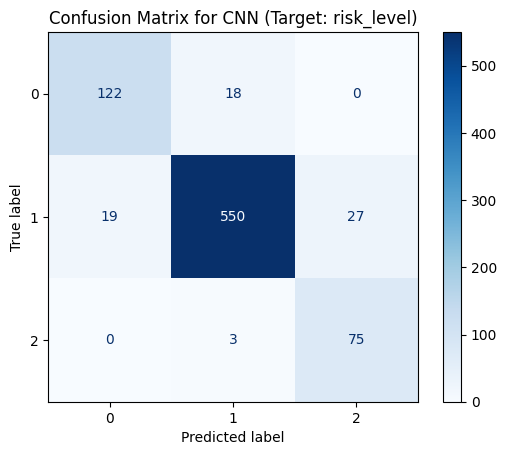

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Evaluate the CNN model on the test set
loss, accuracy = model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"CNN Test Loss: {loss:.4f}")
print(f"CNN Test Accuracy: {accuracy:.4f}")

# Get predictions for the confusion matrix and classification report
y_pred_cnn_probs = model.predict(X_test_cnn)
y_pred_cnn = np.argmax(y_pred_cnn_probs, axis=1)

print("\nClassification Report for CNN (Target: risk_level):\n")
print(classification_report(y_test, y_pred_cnn))

# Generate and display the confusion matrix
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=[0, 1, 2]) # Assuming 0, 1, 2 are your risk levels
disp_cnn.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for CNN (Target: risk_level)')
plt.show()

In [ ]:
pip install eli5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 3.8 MB/s eta 0:00:00


### Feature Importance for CNN using Permutation Importance

Permutation Importance is a technique for computing feature importance for any black-box estimator. It works by shuffling a single feature's values and measuring the drop in model performance. If shuffling a feature significantly drops the model's performance, then that feature is considered important.

In [ ]:
import eli5
from eli5.sklearn import PermutationImportance
import numpy as np # Ensure numpy is imported for np.argmax
import pandas as pd # Ensure pandas is imported for DataFrame check

# PermutationImportance needs a model that can predict probabilities or classes directly.
# Our Keras model's predict method returns probabilities. We need to wrap it
# to get class predictions for accuracy scoring.

class KerasClassifierWrapper:
    def __init__(self, model):
        self.model = model

    # Add get_params for scikit-learn compatibility
    def get_params(self, deep=True):
        return {'model': self.model}

    # Add set_params for scikit-learn compatibility (minimal implementation)
    def set_params(self, **params):
        if 'model' in params:
            self.model = params['model']
        return self

    # Add a dummy fit method to satisfy eli5's estimator check
    def fit(self, X, y=None):
        return self

    def predict(self, X):
        # Convert DataFrame to numpy array if necessary, then reshape for Conv1D input
        if isinstance(X, pd.DataFrame):
            X_array = X.values
        else:
            X_array = X
        # X here will be 2D from eli5's side, so we need to reshape to 3D
        X_reshaped = X_array.reshape(X_array.shape[0], X_array.shape[1], 1)
        return np.argmax(self.model.predict(X_reshaped), axis=1)

    # eli5 expects predict_proba for multi-class classification if scoring='f1_weighted' or similar
    # but for simple accuracy, predict returning classes is sufficient
    def predict_proba(self, X):
        # Convert DataFrame to numpy array if necessary, then reshape for Conv1D input
        if isinstance(X, pd.DataFrame):
            X_array = X.values
        else:
            X_array = X
        # X here will be 2D from eli5's side, so we need to reshape to 3D
        X_reshaped = X_array.reshape(X_array.shape[0], X_array.shape[1], 1)
        return self.model.predict(X_reshaped)

# Create a wrapper for our Keras model
k_model_wrapper = KerasClassifierWrapper(model)

# Initialize PermutationImportance with refit=False since our model is pre-trained
perm = PermutationImportance(k_model_wrapper, scoring='accuracy', random_state=42, cv=None, refit=False)

# Fit on the test data (X_test_scaled_df) and y_test to get importances
# Note: This can be computationally intensive for large datasets or many features.
# Pass X_test_scaled_df (2D) to eli5, the wrapper will reshape it to 3D for the model.
perm.fit(X_test_scaled_df, y_test)

# Display the feature importances
# We need to map the feature indices back to original column names.
# X_train_processed.columns contains the correct feature names.
feature_names = X_train_processed.columns.tolist()

print("Feature Importances for CNN (Target: risk_level) based on Permutation Importance:")
display(eli5.show_weights(perm, feature_names=feature_names))

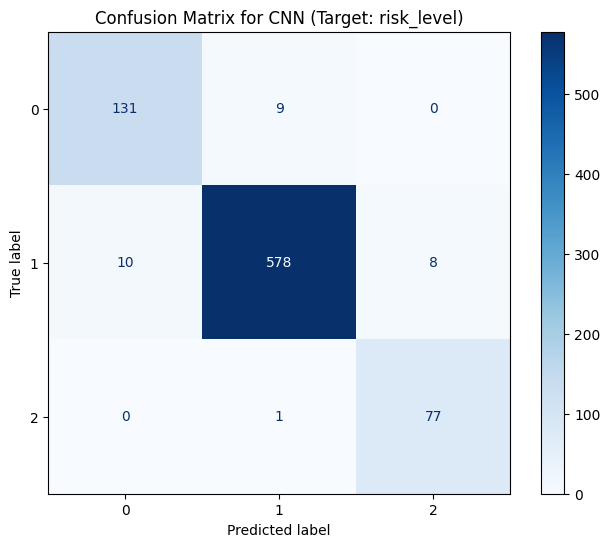

In [ ]:
# Regenerate and display the confusion matrix for the CNN model
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=[0, 1, 2])
fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
disp_cnn.plot(cmap=plt.cm.Blues, ax=ax_cm)
plt.title('Confusion Matrix for CNN (Target: risk_level)')
plt.show()

### Feature Importances for CNN (Target: `risk_level`) - Bar Plot

To provide a visual representation of the CNN's feature importances, similar to the Random Forest Regressor, here is a bar plot derived from the Permutation Importance results.

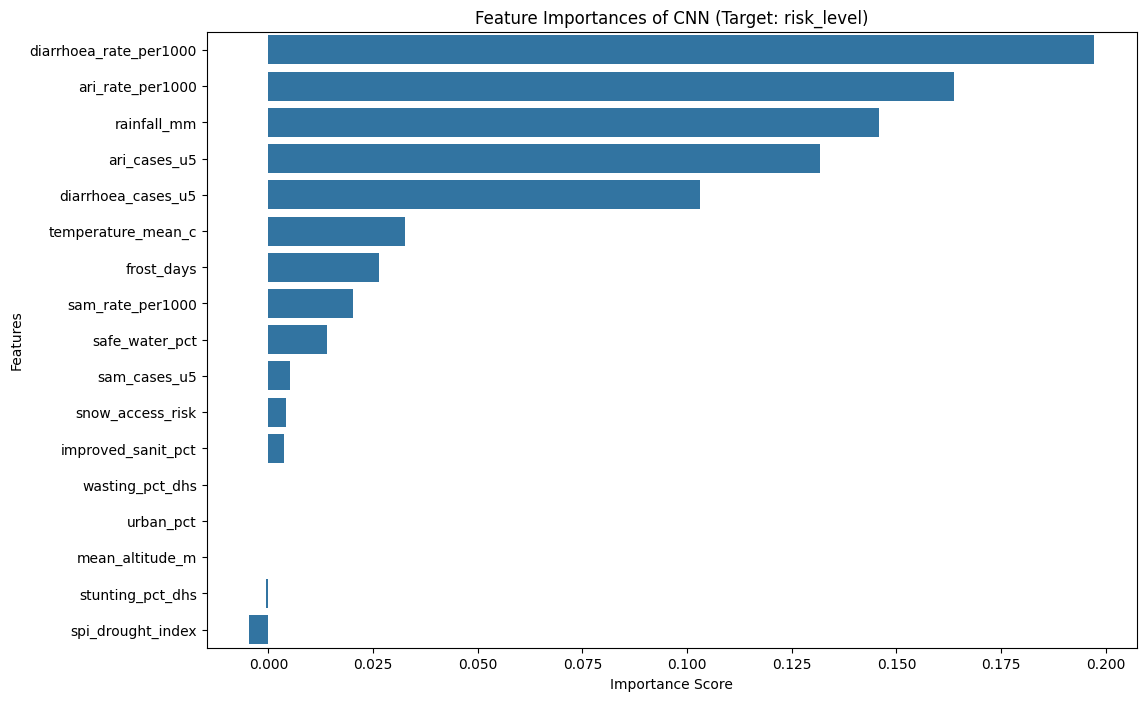

In [ ]:
# Extract feature importances from the PermutationImportance object
cnn_feature_importances = pd.Series(perm.feature_importances_, index=feature_names)
sorted_cnn_feature_importances = cnn_feature_importances.sort_values(ascending=False)

# Visualize CNN feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_cnn_feature_importances.values, y=sorted_cnn_feature_importances.index)
plt.title('Feature Importances of CNN (Target: risk_level)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

### Cross-Validation for CNN Model Stability

To further assess the stability and generalization performance of the CNN model, we will perform k-fold cross-validation on the training data (`X_train_cnn`, `y_train_sm`). This process involves splitting the data into multiple folds, training the model on some folds, and evaluating it on the remaining fold, repeating this process for each fold. This helps in obtaining a more robust estimate of the model's performance.

In [ ]:
from sklearn.model_selection import KFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# Define the number of folds for cross-validation
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Lists to store metrics for each fold
fold_accuracies = []
fold_losses = []

print(f"Starting {n_splits}-fold cross-validation...")

# Perform K-fold cross-validation on the combined training and SMOTE-resampled data
# Since X_train_sm and y_train_sm are already prepared for CNN, we'll use them directly.
# X_train_cnn was derived from X_train_sm, so we'll use the original X_train_sm for splitting
# and then reshape within the loop.

for fold, (train_index, val_index) in enumerate(kf.split(X_train_sm, y_train_sm)):
    print(f"\n--- Fold {fold+1}/{n_splits} ---")

    # Split data for the current fold
    X_train_fold, X_val_fold = X_train_sm.iloc[train_index], X_train_sm.iloc[val_index]
    y_train_fold, y_val_fold = y_train_sm.iloc[train_index], y_train_sm.iloc[val_index]

    # Reshape data for 1D CNN input
    X_train_fold_cnn = X_train_fold.values.reshape(X_train_fold.shape[0], X_train_fold.shape[1], 1)
    X_val_fold_cnn = X_val_fold.values.reshape(X_val_fold.shape[0], X_val_fold.shape[1], 1)

    # Re-define and compile the CNN model for each fold to ensure a fresh start
    model_cv = Sequential([
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train_fold_cnn.shape[1], 1)),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=64, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(units=100, activation='relu'),
        Dropout(0.5),
        Dense(units=3, activation='softmax') # 3 classes for risk_level
    ])
    model_cv.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Train the model for the current fold
    history_cv = model_cv.fit(
        X_train_fold_cnn,
        y_train_fold,
        epochs=10, # Using fewer epochs for CV to save computation time, can be adjusted
        batch_size=32,
        verbose=0 # Set to 1 to see progress for each epoch
    )

    # Evaluate the model on the validation set for the current fold
    loss_cv, accuracy_cv = model_cv.evaluate(X_val_fold_cnn, y_val_fold, verbose=0)
    print(f"Fold {fold+1} - Validation Loss: {loss_cv:.4f}, Validation Accuracy: {accuracy_cv:.4f}")

    fold_losses.append(loss_cv)
    fold_accuracies.append(accuracy_cv)

# Print overall cross-validation results
print("\n--- Cross-Validation Results ---")
print(f"Mean Validation Accuracy: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})")
print(f"Mean Validation Loss: {np.mean(fold_losses):.4f} (+/- {np.std(fold_losses):.4f})")

Starting 5-fold cross-validation...

--- Fold 1/5 ---
Fold 1 - Validation Loss: 0.1090, Validation Accuracy: 0.9587

--- Fold 2/5 ---
Fold 2 - Validation Loss: 0.1185, Validation Accuracy: 0.9471

--- Fold 3/5 ---
Fold 3 - Validation Loss: 0.1465, Validation Accuracy: 0.9398

--- Fold 4/5 ---
Fold 4 - Validation Loss: 0.1435, Validation Accuracy: 0.9398

--- Fold 5/5 ---
Fold 5 - Validation Loss: 0.1420, Validation Accuracy: 0.9456

--- Cross-Validation Results ---
Mean Validation Accuracy: 0.9462 (+/- 0.0069)
Mean Validation Loss: 0.1319 (+/- 0.0152)


### Applying SHAP for CNN Model Explanation

SHAP (SHapley Additive exPlanations) is a game theory-based approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations, providing a more consistent and theoretically sound measure of feature importance compared to other methods.

We will use `shap.GradientExplainer` to calculate SHAP values for our trained CNN model (`model`) on the test dataset. This will reveal how each input feature contributes to the model's prediction for each `risk_level` class.

Generating SHAP Summary Plots...

SHAP Summary Plot for Low Risk (0):


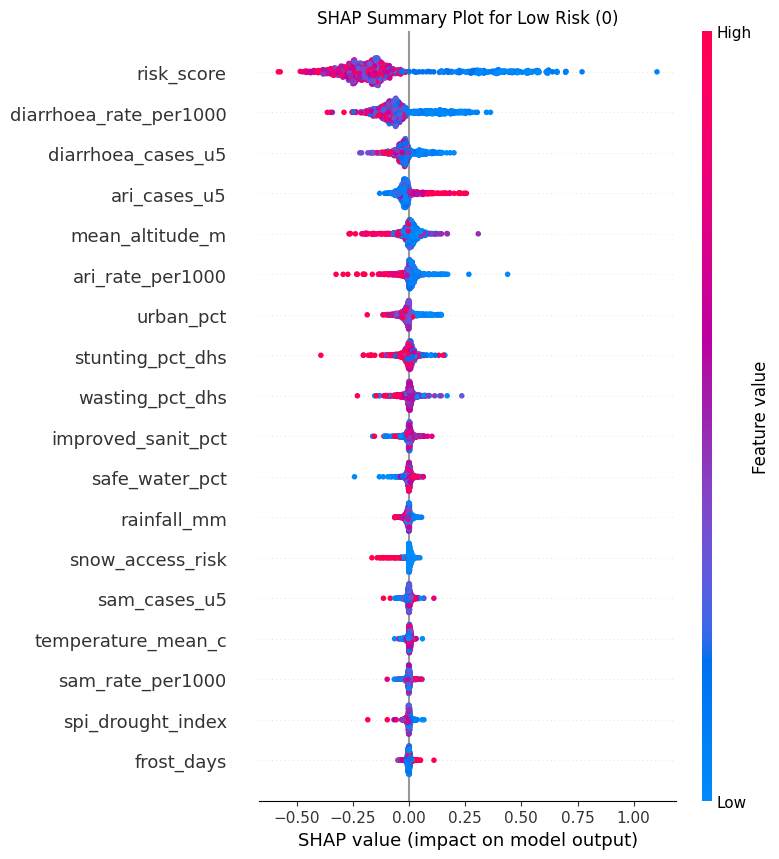


SHAP Summary Plot for Medium Risk (1):


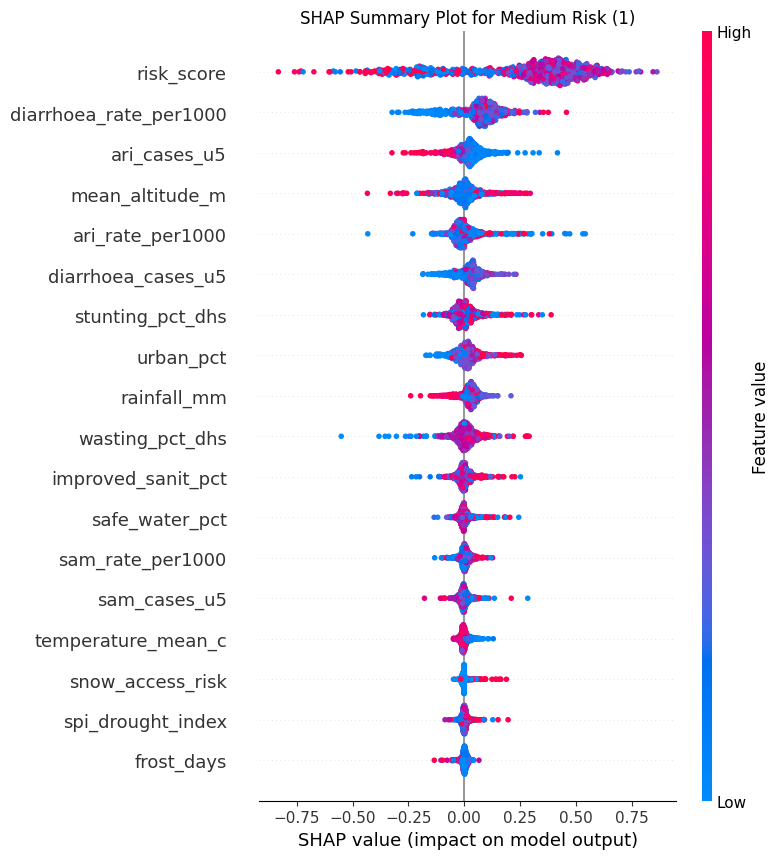


SHAP Summary Plot for High Risk (2):


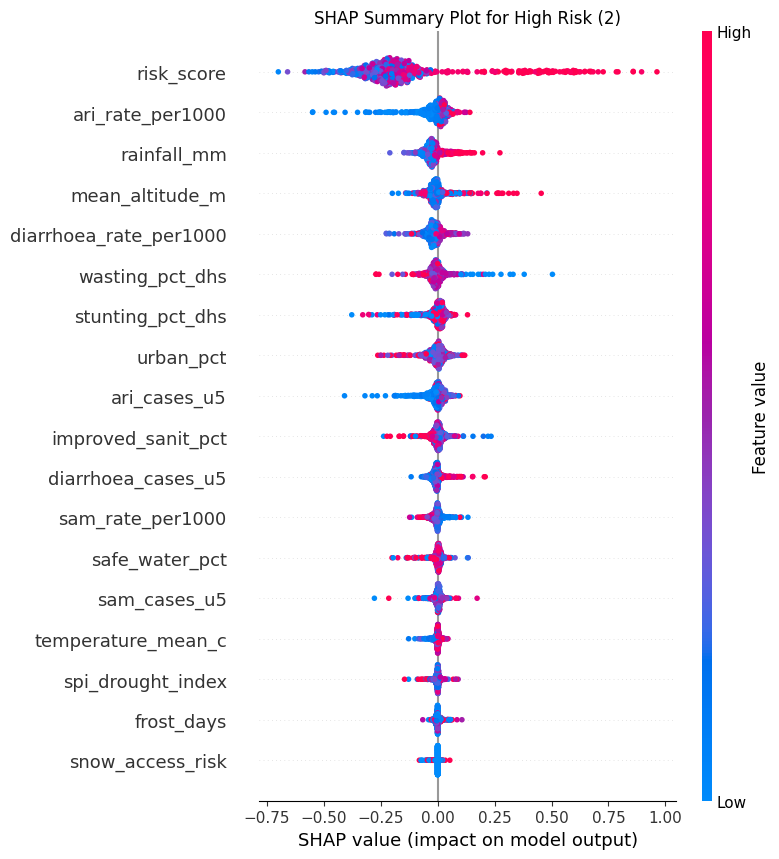


Overall SHAP Summary Bar Plot (Mean Absolute SHAP values across all classes):



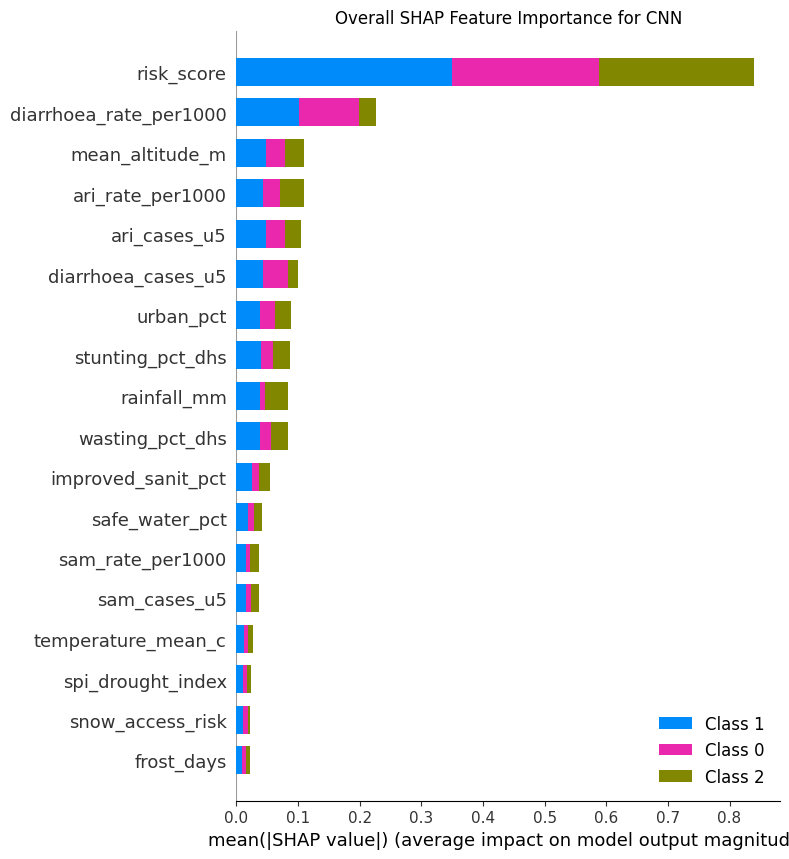

In [ ]:
import shap
import matplotlib.pyplot as plt

# Map the integer risk_level to meaningful labels for the plot
class_names = ['Low Risk (0)', 'Medium Risk (1)', 'High Risk (2)']

print("Generating SHAP Summary Plots...")

# Initialize SHAP GradientExplainer for the CNN model
# X_train_cnn is used as the background dataset for the explainer
explainer = shap.GradientExplainer(model, X_train_cnn)

# Calculate SHAP values for the test data
# Based on kernel state, shap_values is a single array of shape (num_samples, num_features, 1, num_classes)
shap_values = explainer.shap_values(X_test_cnn)

# Correctly extract class-specific SHAP values and squeeze the channel dimension
num_classes = shap_values.shape[-1]
class_shap_values = []
for k in range(num_classes):
    # Extract shap values for all samples and features for class k
    # This results in an array of shape (num_samples, num_features, 1)
    shap_for_class_k = shap_values[:, :, :, k]
    # .squeeze() removes the singleton dimension (channel dimension), resulting in (num_samples, num_features)
    class_shap_values.append(shap_for_class_k.squeeze())

# Display summary plot for each class
for i, class_name in enumerate(class_names):
    print(f"\nSHAP Summary Plot for {class_name}:")
    # Use the correctly prepared class_shap_values[i] (shape: num_samples, num_features)
    shap.summary_plot(class_shap_values[i], X_test_scaled_df.values, feature_names=X_test_scaled_df.columns.tolist(), show=False)
    plt.title(f"SHAP Summary Plot for {class_name}")
    plt.tight_layout()
    plt.show()

# For an overall view, we can also plot the mean absolute SHAP values across all classes
# This gives a general idea of global feature importance without separating by class.
print("\nOverall SHAP Summary Bar Plot (Mean Absolute SHAP values across all classes):\n")
# For the overall plot, shap.summary_plot expects a list of (num_samples, num_features) arrays,
# which is exactly what class_shap_values is.
shap.summary_plot(class_shap_values, X_test_scaled_df.values, feature_names=X_test_scaled_df.columns.tolist(), plot_type="bar", show=False)
plt.title("Overall SHAP Feature Importance for CNN")
plt.tight_layout()
plt.show()

Random Forest Classifier trained successfully.

Classification Report for Random Forest (Target: risk_level):

              precision    recall  f1-score   support

           0       0.89      0.94      0.92       140
           1       0.97      0.96      0.96       596
           2       0.88      0.86      0.87        78

    accuracy                           0.95       814
   macro avg       0.91      0.92      0.92       814
weighted avg       0.95      0.95      0.95       814



<Figure size 800x600 with 0 Axes>

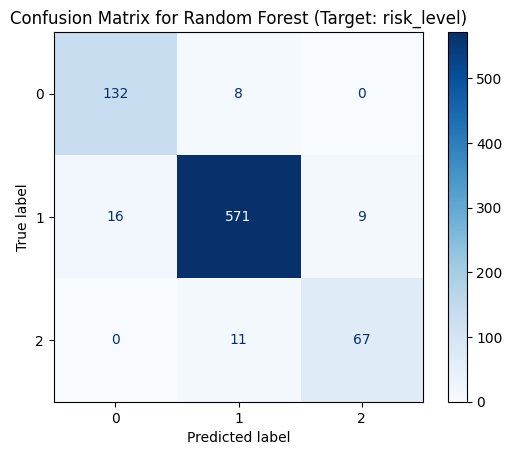

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Initialize and train a RandomForestClassifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_sm, y_train_sm)

print("Random Forest Classifier trained successfully.")

# Make predictions on the scaled test set
y_pred_rf = rf_classifier.predict(X_test_scaled_df)

# Evaluate the Random Forest Classifier
print("\nClassification Report for Random Forest (Target: risk_level):\n")
print(classification_report(y_test, y_pred_rf))

# Generate and display the confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=[0, 1, 2])

plt.figure(figsize=(8, 6))
disp_rf.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Random Forest (Target: risk_level)')
plt.show()